# WARMUP | Advanced Plotting & Functions

<video src="../../_static/videos/tcw_animation.mp4" controls width="600" controls="controls" muted="muted" class="d-block rounded-bottom-2 border-top width-fit" style="max-height:640px; min-height: 200px"></video>

In the next 60 minutes, you will create a function that can generate frames for an animation like the one above.  Later in the lesson, we'll use this function to demonstrate parallelization with `mpi4py`.

For context, the plot shows total atmospheric water (*precipitable water* is the technical term), which is a good way to look at [atmospheric rivers](https://www.noaa.gov/stories/what-are-atmospheric-rivers).

## 1. Make a nice plot

1. Create a notebook in your lesson 07 folder.
2. Make a plot that looks as close as possible to the above plot.
   * Use `xarray` to read the data file `/N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc`
    * the variable name in the file is `TCW`
    * select a specific timestep by index using `xarray`'s `isel()` method
   * Use `matplotlib`, `cartopy`, and `cmocean` to make the plot pretty
   * Save the figure as a 300 dpi PNG file
   * *Hint: the plot uses an Orthographic projection, and the center latitude and longitude correspond to Bloomington, IN* 
3. Make sure to comment your code thoroughly!

## 2. Make a plotting function

Now you're going to write a function that can generate and save an image, like the one you just created, for an arbitrary timestep in the file.

1. In the same notebook, create a function called `generate_frame()` that takes three arguments:
    * `i` - the timestep index to plot
    * `input_file` - the file from which to get data
    * `output_dir` - the directory to which to save the image
2. Copy the code that you wrote into the function as a starting point
3. Test that the function works as expected; revise the function until it does
    * *Hints:*
        * You can use a command like `os.makedirs(output_dir, exist_ok=True)` to ensure that the output directory exists before you try to save files to it.
        * Add `plt.ioff()` at the start of your function to prevent figures from displaying in the notebook when the function is called.
        * Add `plt.close()` at the end of your function (after `plt.savefig()` is called) to prevent memory issues when generating many figures.
4. Commit and push the notebook to your GitHub repo

In [1]:
# import libraries
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import cartopy
import cmocean
import os

In [2]:
# set the path to the input data file
input_file = "/N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc"

# set the directory where we'll save the images
output_dir = "./animation_frames"

# set the timestep to plot
i = 0

# make sure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# load the data file
ds_in = xr.open_dataset(input_file, chunks = -1)
ds_in

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 720, latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 6kB 2021-06-01 ... 2021-06-30T23:00:00
Data variables:
    TCW        (time, latitude, longitude) float32 3GB dask.array<chunksize=(720, 721, 1440), meta=np.ndarray>
    utc_date   (time) int32 3kB dask.array<chunksize=(720,), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.7.4
    CONVERSION_PLATFORM:  Linux r4i1n35 4.12.14-95.51-default #1 SMP Fri Apr ...
    CONVERSION_DATE:      Fri Sep  3 11:04:41 MDT 2021
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Fri Sep  3 11:04:57 2021: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.9.5 (Homepage = http://n...

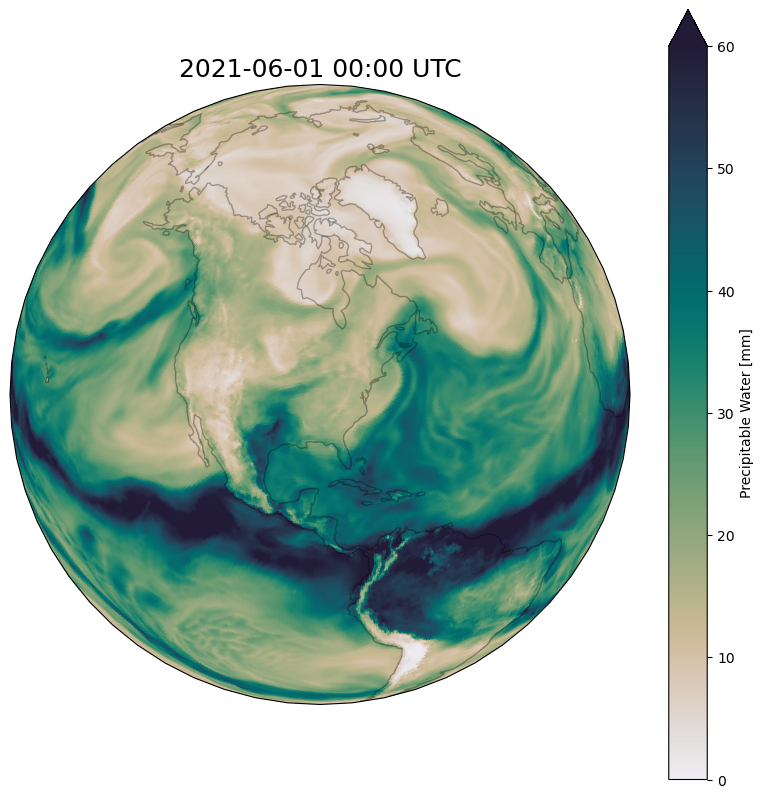

In [3]:
# get the variable at the requested timestep
tcw = ds_in['TCW'].isel(time=i)

# plot the variable on an orthographic projection centered on
# Bloomington, IN
clat = 39.1653
clon = -86.5264
projection = cartopy.crs.Orthographic(clon, clat)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=projection))

# plot the data
tcw.plot(
    ax = ax,
    transform = cartopy.crs.PlateCarree(),
    cmap = cmocean.cm.rain,
    cbar_kwargs = dict(label = f'Precipitable Water [mm]'),
    vmin = 0,
    vmax = 60,
)

# get the time of the timestep
time = tcw.time.values

# convert it to a datetime object
time = pd.to_datetime(time)

# add a title with a nicely formatted date
ax.set_title(time.strftime("%Y-%m-%d %H:%M UTC"), fontsize=18)

# add coastlines
ax.coastlines(alpha = 0.3)

# save the plot
output_file = os.path.join(output_dir, f"tcw_{i:05d}.png")
fig.savefig(output_file, dpi=300, bbox_inches="tight")

plt.show()

In [4]:
""" Make a function to plot and save the data at a given timestep. """

def generate_frame(
        i : int,
        input_file = "/N/project/obrienta_startup/datasets/ERA5/ds633.0/e5.oper.an.sfc/202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc",
        output_dir = "./animation_frames/"):

        # prevent matplotlib from displaying the plot
        plt.ioff()

        # make sure the output directory exists
        os.makedirs(output_dir, exist_ok=True)

        # load the data file
        ds_in = xr.open_dataset(input_file, chunks = -1)

        # get the variable at the requested timestep
        tcw = ds_in['TCW'].isel(time=i)

        # plot the variable on an orthographic projection centered on
        # Bloomington, IN
        clat = 39.1653
        clon = -86.5264
        projection = cartopy.crs.Orthographic(clon, clat)
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=projection))

        # plot the data
        tcw.plot(
        ax = ax,
        transform = cartopy.crs.PlateCarree(),
        cmap = cmocean.cm.rain,
        cbar_kwargs = dict(label = f'Precipitable Water [mm]'),
        vmin = 0,
        vmax = 60,
        )

        # get the time of the timestep
        time = tcw.time.values

        # convert it to a datetime object
        time = pd.to_datetime(time)

        # add a title with a nicely formatted date
        ax.set_title(time.strftime("%Y-%m-%d %H:%M UTC"), fontsize=18)

        # add coastlines
        ax.coastlines(alpha = 0.3)

        # save the plot
        output_file = os.path.join(output_dir, f"tcw_{i:05d}.png")
        # save the plot
        fig.savefig(output_file, dpi=300, bbox_inches="tight")

        # close the figure
        plt.close(fig)

        return output_file

In [5]:
""" Test the function. """

# set the timestep to plot (select a new timestep)
i = 1

# generate the plot
generate_frame(i)

'./animation_frames/tcw_00001.png'